### *E-commerce Return Rate Analysis*
E-commerce Return Rate Analysis | Product Performance Insights from Online Retail Data

### *Tools Used* 
Python, Pandas, Matplotlib, Seaborn.
	
### *Description* 
An end-to-end data analytics project using a curated e-commerce dataset to uncover patterns in product performance and return behavior across various categories. The analysis focuses on identifying key factors such as pricing, discount rates, customer ratings, delivery speed, and stock availability that influence return rates. By exploring relationships between these variables, the project aims to provide actionable insights to optimize product strategies, enhance customer satisfaction, and reduce return-related losses.

### *Business Problem*
How can an e-commerce company improve product performance and reduce return rates by analyzing the relationship between pricing, discounts, customer ratings, delivery speed, and stock availability across different product categories?


- *Author* - *Niranjan (Data Analyst)*

### *Environmental Setup*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) 
import warnings
warnings.filterwarnings("ignore")

### *Data Loading*

In [2]:
df = pd.read_csv("ecommerce_product_performance.csv")

### *Data Understanding*

In [3]:
df.head(5)

,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID
0,199.671415,0.177024,4.411071,62.0,1.0,9.0,0.185116,5.0
1,136.173570,0.041467,3.033534,201.0,1.0,3.0,0.384639,10.0
2,214.768854,0.276197,2.866881,479.0,1.0,19.0,0.056410,4.0
3,302.302986,0.094254,4.473473,252.0,1.0,11.0,NaN,7.0
4,126.584663,0.411845,3.553082,671.0,1.0,14.0,0.672163,6.0


In [4]:
df.shape

(2000, 8)

In [5]:
df.columns.to_list()

['Product_Price',
 'Discount_Rate',
 'Product_Rating',
 'Number_of_Reviews',
 'Stock_Availability',
 'Days_to_Deliver',
 'Return_Rate',
 'Category_ID']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_Price       1900 non-null   float64
 1   Discount_Rate       1900 non-null   float64
 2   Product_Rating      1900 non-null   float64
 3   Number_of_Reviews   1900 non-null   float64
 4   Stock_Availability  1900 non-null   float64
 5   Days_to_Deliver     1900 non-null   float64
 6   Return_Rate         1900 non-null   float64
 7   Category_ID         1900 non-null   float64
dtypes: float64(8)
memory usage: 125.1 KB


### *Data Exploration*

*Product Price*

In [7]:
df["Product_Price"].unique()

array([199.6714153 , 136.17356988, 214.76885381, ...,  61.81253488,
       133.69330361,  75.50973552])

In [8]:
df["Product_Price"].nunique()

1781

In [9]:
df["Product_Price"].skew()

0.33119570646531044

<Axes: xlabel='Product_Price', ylabel='Count'>

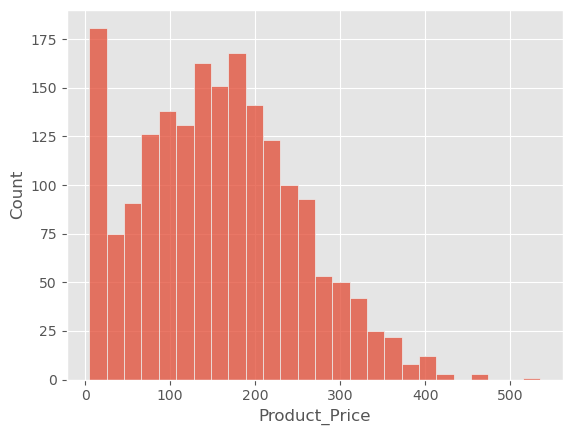

In [10]:
sns.histplot(data = df, x = "Product_Price")

<Axes: xlabel='Product_Price'>

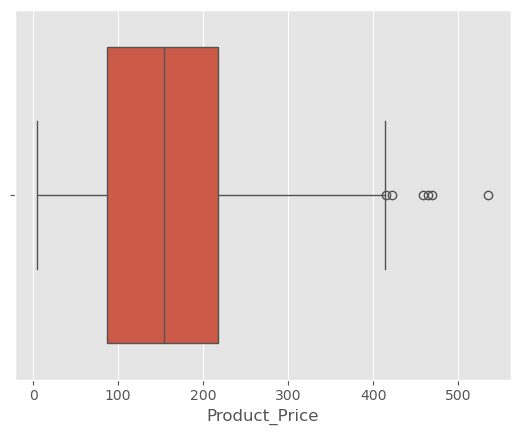

In [11]:
sns.boxplot(data = df, x = "Product_Price")

*Outliers in Product Price*

*Discount Rate*

In [12]:
df["Discount_Rate"].unique()

array([0.17702361, 0.04146698, 0.27619741, ..., 0.08161595, 0.34615132,
       0.66974241])

In [13]:
df["Discount_Rate"].nunique()

1899

In [14]:
df["Discount_Rate"].skew()

0.5581382723202687

<Axes: xlabel='Discount_Rate', ylabel='Count'>

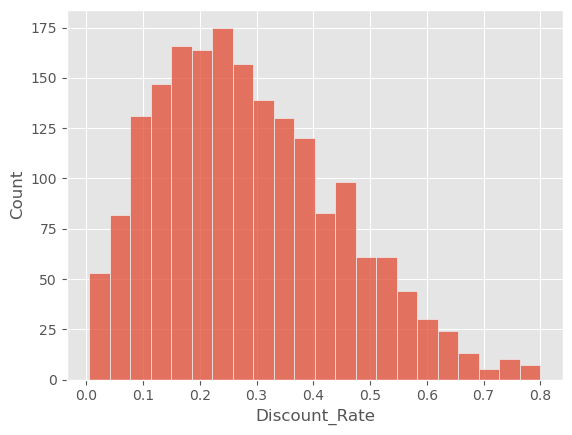

In [15]:
sns.histplot(data = df, x = "Discount_Rate")

<Axes: xlabel='Discount_Rate'>

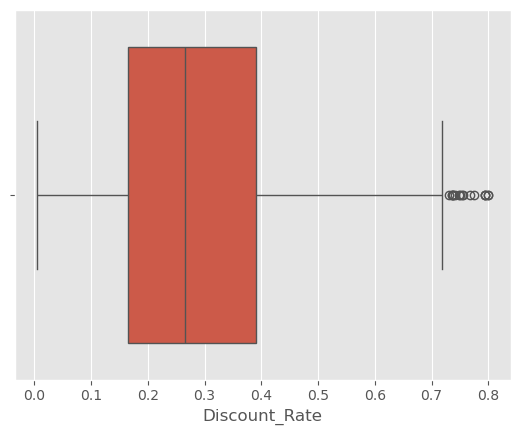

In [16]:
sns.boxplot(data = df, x = "Discount_Rate")

#### *Product Rating*

In [17]:
df["Product_Rating"].unique()

array([4.41107091, 3.03353357, 2.86688091, ..., 2.73674131, 3.246759  ,
       3.22629686])

In [18]:
df["Product_Rating"].nunique()

1698

In [19]:
df['Product_Rating'].describe() 

count    1900.000000
mean        3.729987
std         0.885164
min         1.000000
25%         3.125828
50%         3.770215
75%         4.417711
max         5.000000
Name: Product_Rating, dtype: float64

#### *Number of reviews*

In [20]:
df['Number_of_Reviews'].dtype

dtype('float64')

In [21]:
df['Number_of_Reviews'].isnull().sum()

100

In [22]:
df['Number_of_Reviews'].nunique()
df['Number_of_Reviews'].unique()[:10]  # peek at top value

array([ 62., 201., 479., 252., 671., 303., 350., 330., 179.,  nan])

In [23]:
df['Number_of_Reviews'].describe()

count    1900.000000
mean      304.318421
std       310.344539
min         0.000000
25%        86.750000
50%       210.000000
75%       429.000000
max      2848.000000
Name: Number_of_Reviews, dtype: float64

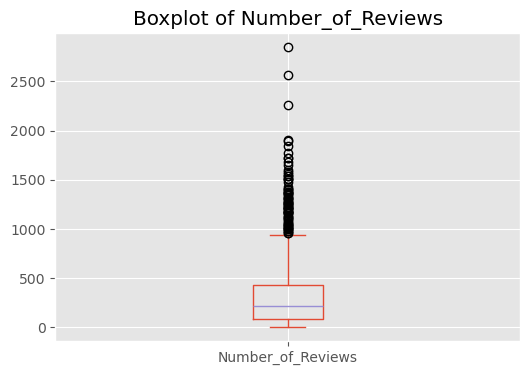

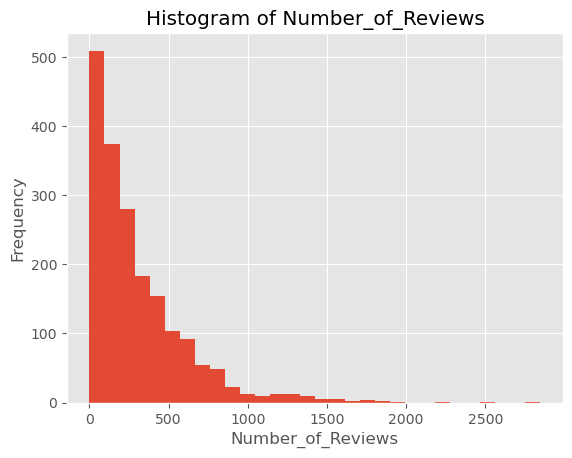

In [24]:
plt.figure(figsize=(6, 4))
df['Number_of_Reviews'].plot(kind='box')
plt.title('Boxplot of Number_of_Reviews')
plt.show()

df['Number_of_Reviews'].hist(bins=30)
plt.title('Histogram of Number_of_Reviews')
plt.xlabel('Number_of_Reviews')
plt.ylabel('Frequency')
plt.show()

In [25]:
df["Number_of_Reviews"].skew()

2.222379349709922

#### *Stock Availability*

In [26]:
df['Stock_Availability'].dtype

dtype('float64')

In [27]:
df['Stock_Availability'].isnull().sum()

100

In [28]:
df['Stock_Availability'].unique()
df['Stock_Availability'].value_counts()

Stock_Availability
1.0    1716
0.0     184
Name: count, dtype: int64

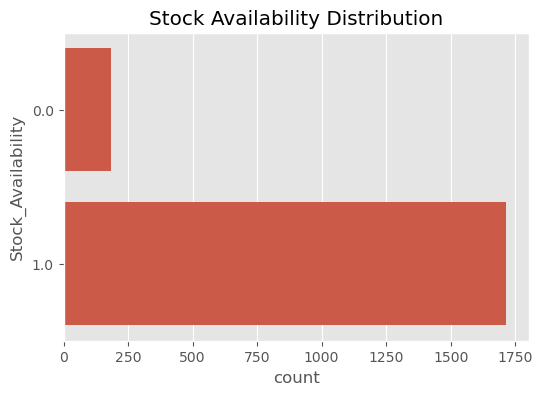

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(y='Stock_Availability', data=df)
plt.title('Stock Availability Distribution')
plt.show()

#### *Days to deliver*

In [30]:
df['Days_to_Deliver'].dtype

dtype('float64')

In [31]:
df['Days_to_Deliver'].isnull().sum()

100

In [32]:
df['Days_to_Deliver'].unique()
df['Days_to_Deliver'].value_counts().sort_index()

Days_to_Deliver
1.0     58
2.0     61
3.0     62
4.0     75
5.0     58
6.0     54
7.0     76
8.0     56
9.0     51
10.0    58
11.0    68
12.0    64
13.0    83
14.0    75
15.0    74
16.0    62
17.0    71
18.0    61
19.0    69
20.0    63
21.0    65
22.0    64
23.0    58
24.0    52
25.0    53
26.0    49
27.0    67
28.0    64
29.0    65
30.0    64
Name: count, dtype: int64

In [33]:
df['Days_to_Deliver'].describe()

count    1900.000000
mean       15.411579
std         8.534049
min         1.000000
25%         8.000000
50%        15.000000
75%        22.000000
max        30.000000
Name: Days_to_Deliver, dtype: float64

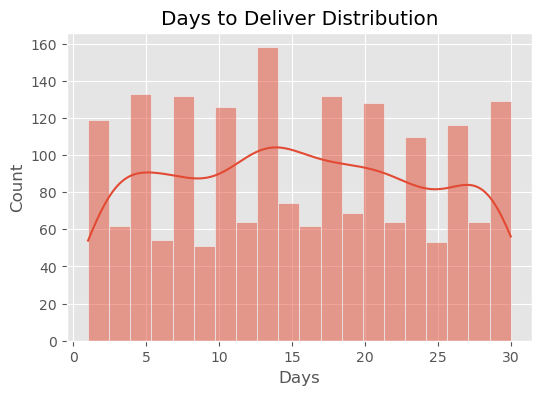

In [34]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Days_to_Deliver'], bins=20, kde=True)
plt.title('Days to Deliver Distribution')
plt.xlabel('Days')
plt.show()

#### *Return Rate*

In [35]:
df['Return_Rate'].dtype

dtype('float64')

In [36]:
df['Return_Rate'].isnull().sum()

100

In [37]:
df['Return_Rate'].unique()

array([0.18511563, 0.38463904, 0.05641014, ..., 0.29351977, 0.36283373,
       0.20458894])

In [38]:
df['Return_Rate'].describe()

count    1900.000000
mean        0.328904
std         0.176306
min         0.006528
25%         0.190178
50%         0.307430
75%         0.444752
max         0.900000
Name: Return_Rate, dtype: float64

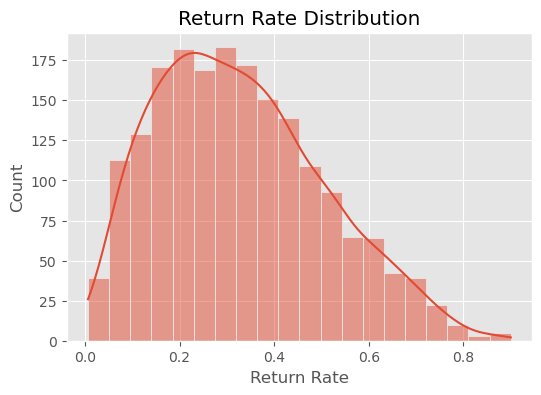

In [39]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Return_Rate'], bins=20, kde=True)
plt.title('Return Rate Distribution')
plt.xlabel('Return Rate')
plt.show()

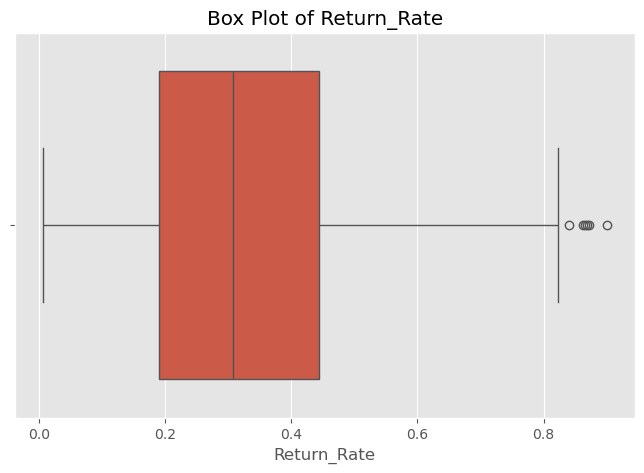

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Return_Rate'])
plt.title('Box Plot of Return_Rate')
plt.show()

#### *CAtegory ID*

In [41]:
df['Category_ID'].dtype

dtype('float64')

In [42]:
df['Category_ID'].nunique()

10

In [43]:
df['Category_ID'].isnull().sum()

100

In [44]:
df['Category_ID'].value_counts()

Category_ID
8.0     210
7.0     206
6.0     206
9.0     195
5.0     188
1.0     186
4.0     185
3.0     176
2.0     175
10.0    173
Name: count, dtype: int64

### *Data Cleaning*

*Checking for the duplicates in the data set*

In [45]:
df.duplicated().sum()

0

*Check for the Datatype*

In [46]:
df.dtypes

Product_Price         float64
Discount_Rate         float64
Product_Rating        float64
Number_of_Reviews     float64
Stock_Availability    float64
Days_to_Deliver       float64
Return_Rate           float64
Category_ID           float64
dtype: object

In [47]:
df['Number_of_Reviews'] = pd.to_numeric(df['Number_of_Reviews'], errors='coerce')

df['Days_to_Deliver'] = pd.to_numeric(df['Days_to_Deliver'], errors='coerce')

*Check for the missing values*

In [48]:
df.isnull().sum()

Product_Price         100
Discount_Rate         100
Product_Rating        100
Number_of_Reviews     100
Stock_Availability    100
Days_to_Deliver       100
Return_Rate           100
Category_ID           100
dtype: int64

*Handle missing values*

In [49]:
# For numeric columns, fill missing values with median (robust to outliers)
numeric_cols = ['Product_Price', 'Discount_Rate', 'Product_Rating', 'Number_of_Reviews', 'Days_to_Deliver', 'Return_Rate']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# For categorical column 'Stock_Availability', fill missing values with mode (most frequent)
df['Stock_Availability'].fillna(df['Stock_Availability'].mode()[0], inplace=True)

# For 'Category_ID' (assuming categorical), also fill with mode
df['Category_ID'].fillna(df['Category_ID'].mode()[0], inplace=True)

*Handle outliers*

In [50]:
# Calculate IQR
Q1 = df['Product_Price'].quantile(0.25)
Q3 = df['Product_Price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers
df['Product_Price'] = df['Product_Price'].clip(lower=lower_bound, upper=upper_bound)

In [51]:
# Calculate IQR
Q1 = df['Discount_Rate'].quantile(0.25)
Q3 = df['Discount_Rate'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers
df['Discount_Rate'] = df['Discount_Rate'].clip(lower=lower_bound, upper=upper_bound)

In [52]:
Q1 = df['Number_of_Reviews'].quantile(0.25)
Q3 = df['Number_of_Reviews'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap the outliers
df['Number_of_Reviews'] = df['Number_of_Reviews'].clip(lower=lower_bound, upper=upper_bound)

In [53]:
Q1 = df['Return_Rate'].quantile(0.25)
Q3 = df['Return_Rate'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Cap the outliers
df['Return_Rate'] = df['Return_Rate'].clip(lower=lower, upper=upper)

*Featured Enginerring*

In [54]:
def rating_category(r):
    if r >= 4.0:
        return "Excellent"
    elif r >= 3.0:
        return "Good"
    elif r >= 2.0:
        return "Average"
    elif r >= 1.0:
        return "Poor"
    else:
        return "Very Poor"

df['Rating_Category'] = df['Product_Rating'].apply(rating_category)

In [55]:
df['Rating_Category'].value_counts(normalize=True) * 100

Rating_Category
Good         40.90
Excellent    39.00
Average      16.95
Poor          3.15
Name: proportion, dtype: float64

In [56]:
# First fill 'Product_Rating' and 'Days_to_Deliver' as above

# Then recreate derived columns
df['Rating_Category'] = pd.cut(df['Product_Rating'],
                               bins=[0, 2, 3.5, 5],
                               labels=['Low', 'Average', 'High'],
                               include_lowest=True)

df['Delivery_Speed'] = pd.cut(df['Days_to_Deliver'],
                              bins=[0, 3, 7, 30],
                              labels=['Fast', 'Moderate', 'Slow'],
                              include_lowest=True)

In [57]:
df['Stock_Availability'] = df['Stock_Availability'].map({1: 'Yes', 0: 'No'})

In [58]:
df.shape

(2000, 10)

In [59]:
continuous = ['Product_Price', 'Discount_Rate', 'Product_Rating', 'Number_of_Reviews', 'Days_to_Deliver', 'Return_Rate']
categorical = ['Category_ID', 'Rating_Category', 'Delivery_Speed','Stock_Availability']

### *Data Analysis*

*Does product price vary significantly across categories?*

In [60]:
df.groupby('Category_ID')['Product_Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Category_ID,,,,,,,,
1.0,186.0,149.754035,80.551832,5.0,89.666920,153.136228,192.322638,369.045563
2.0,175.0,157.265238,91.988781,5.0,90.823251,155.194589,218.717705,398.313164
3.0,176.0,162.446501,90.427634,5.0,98.847652,153.663352,230.439800,398.313164
4.0,185.0,156.003813,92.517982,5.0,87.685947,153.663352,218.189149,398.313164
5.0,188.0,155.482930,88.882608,5.0,93.016829,154.110268,205.942598,398.313164
6.0,206.0,150.889647,87.285931,5.0,83.577616,153.037449,210.688895,398.313164
7.0,206.0,146.193750,92.875976,5.0,78.461892,143.115947,201.248968,398.313164
8.0,310.0,156.878493,93.014099,5.0,89.565959,153.663352,211.417205,398.313164
9.0,195.0,161.902935,91.454784,5.0,92.316251,159.767610,222.556562,398.313164


*Is there a correlation between discount rate and return rate?*

In [61]:
df[['Discount_Rate', 'Return_Rate']].corr()

,Discount_Rate,Return_Rate
Discount_Rate,1.000000,0.031941
Return_Rate,0.031941,1.000000


*Which categories have the highest average return rates?*

In [62]:
df.groupby('Category_ID')['Return_Rate'].mean().sort_values(ascending=False)

Category_ID
3.0     0.341100
8.0     0.339349
10.0    0.335136
5.0     0.335055
1.0     0.326686
7.0     0.325780
9.0     0.323392
4.0     0.319751
6.0     0.314564
2.0     0.308662
Name: Return_Rate, dtype: float64

*Do better-rated products have lower return rates?*

In [63]:
df.groupby('Rating_Category')['Return_Rate'].mean()

Rating_Category
Low        0.336824
Average    0.322769
High       0.329638
Name: Return_Rate, dtype: float64

*How does delivery speed affect return rates?*

In [64]:
df.groupby('Delivery_Speed')['Return_Rate'].mean()

Delivery_Speed
Fast        0.328427
Moderate    0.331735
Slow        0.326745
Name: Return_Rate, dtype: float64

*Is product rating influenced by price or discount?*

In [65]:
df[['Product_Price', 'Discount_Rate', 'Product_Rating']].corr()

,Product_Price,Discount_Rate,Product_Rating
Product_Price,1.000000,0.005389,-0.005347
Discount_Rate,0.005389,1.000000,0.008653
Product_Rating,-0.005347,0.008653,1.000000


*What’s the stock availability across product categories?*

In [66]:
pd.crosstab(df['Category_ID'], df['Stock_Availability'])

Stock_Availability,No,Yes
Category_ID,,
1.0,17,169
2.0,12,163
3.0,16,160
4.0,18,167
5.0,17,171
6.0,21,185
7.0,16,190
8.0,27,283
9.0,21,174


*Are more reviewed products returned less?*

In [67]:
df[['Number_of_Reviews', 'Return_Rate']].corr()

,Number_of_Reviews,Return_Rate
Number_of_Reviews,1.00000,0.00983
Return_Rate,0.00983,1.00000


*Which category is most balanced in price, rating, and return rate?*

### *Data Visualization*
*Product Price Distribution Across Categories*

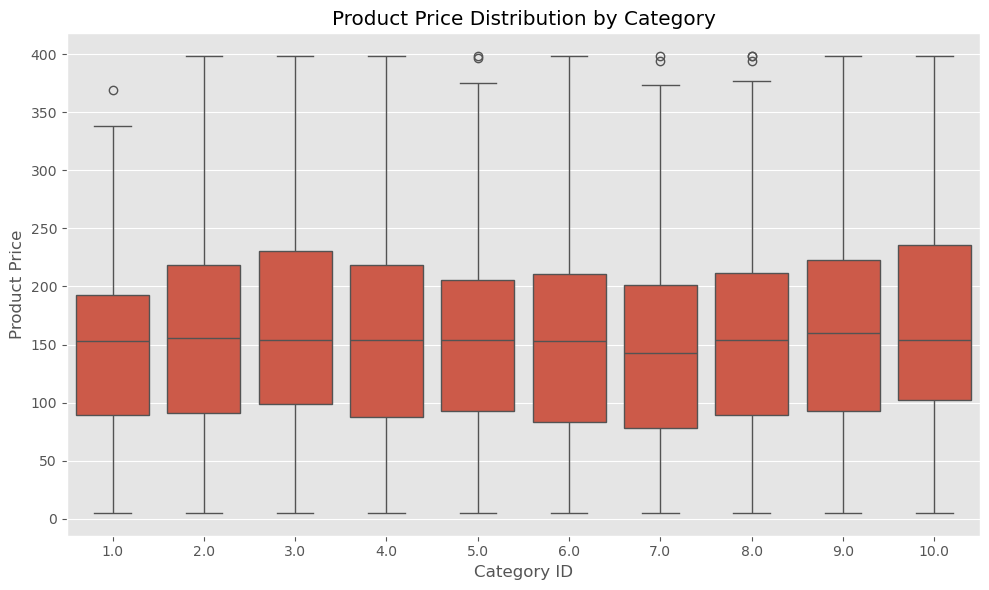

In [68]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category_ID', y='Product_Price')
plt.title('Product Price Distribution by Category')
plt.xlabel('Category ID')
plt.ylabel('Product Price')
plt.tight_layout()
plt.show()

*Correlation: Discount vs Return Rate*

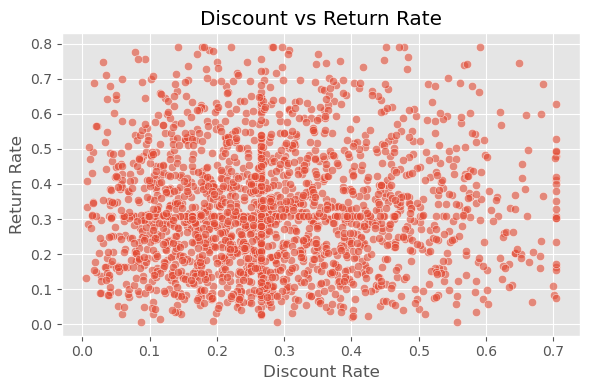

In [69]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Discount_Rate', y='Return_Rate', alpha=0.6)
plt.title('Discount vs Return Rate')
plt.xlabel('Discount Rate')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()

*Average Return Rate by Category*

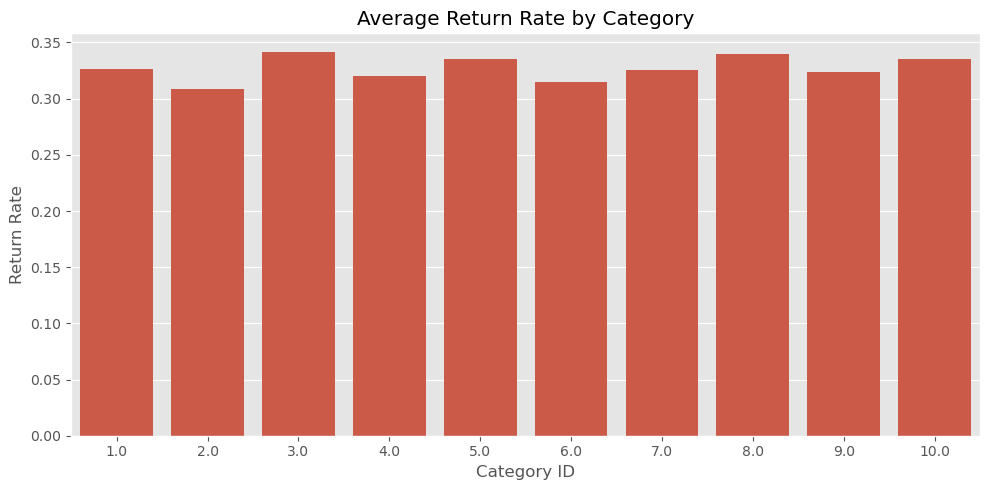

In [70]:
plt.figure(figsize=(10, 5))
category_returns = df.groupby('Category_ID')['Return_Rate'].mean().sort_values()
sns.barplot(x=category_returns.index, y=category_returns.values)
plt.title('Average Return Rate by Category')
plt.xlabel('Category ID')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()

*Return Rate by Rating Category*

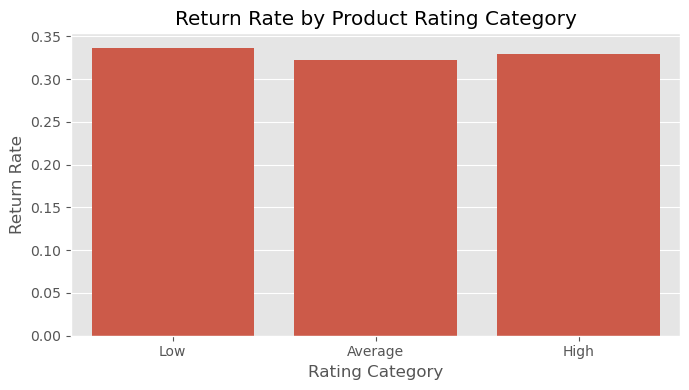

In [71]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='Rating_Category', y='Return_Rate', ci=None)
plt.title('Return Rate by Product Rating Category')
plt.xlabel('Rating Category')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()

*Return Rate by Delivery Speed*

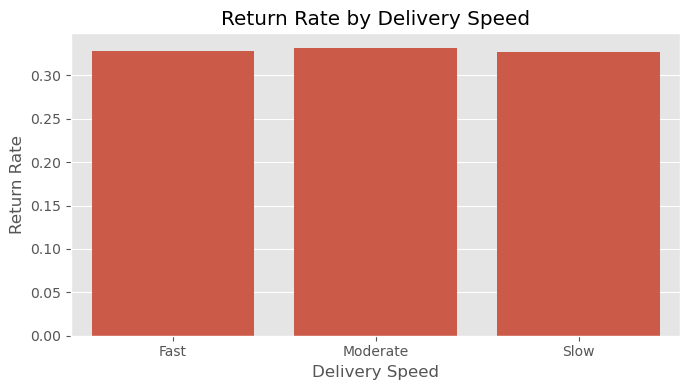

In [72]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='Delivery_Speed', y='Return_Rate', ci=None)
plt.title('Return Rate by Delivery Speed')
plt.xlabel('Delivery Speed')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()

*Product Rating vs Discount & Price (Correlation Heatmap)*

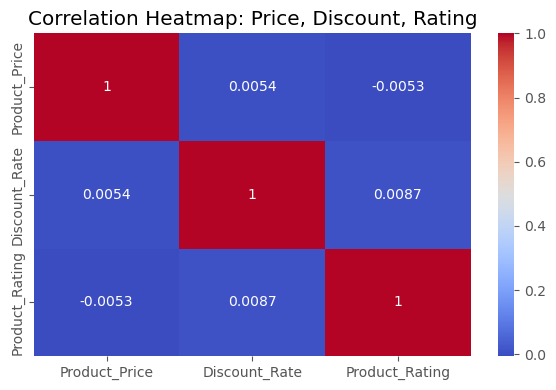

In [73]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['Product_Price', 'Discount_Rate', 'Product_Rating']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Price, Discount, Rating')
plt.tight_layout()
plt.show()

*Stock Availability by Category (Count Plot)*

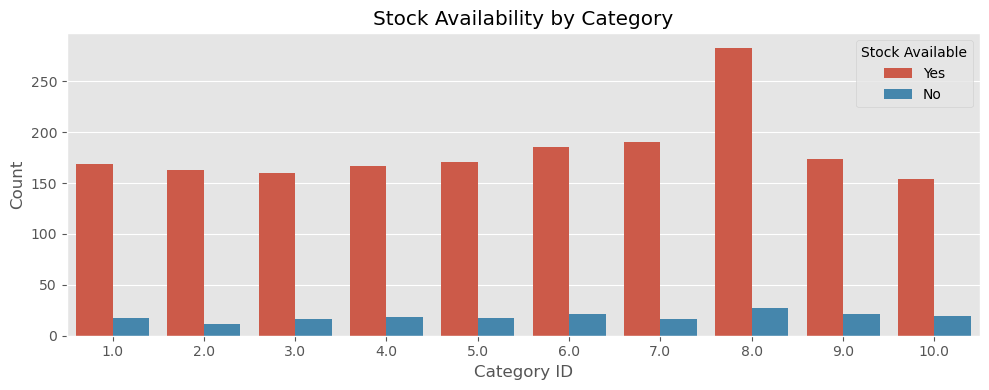

In [74]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Category_ID', hue='Stock_Availability')
plt.title('Stock Availability by Category')
plt.xlabel('Category ID')
plt.ylabel('Count')
plt.legend(title='Stock Available')
plt.tight_layout()
plt.show()

*Reviews vs Return Rate*

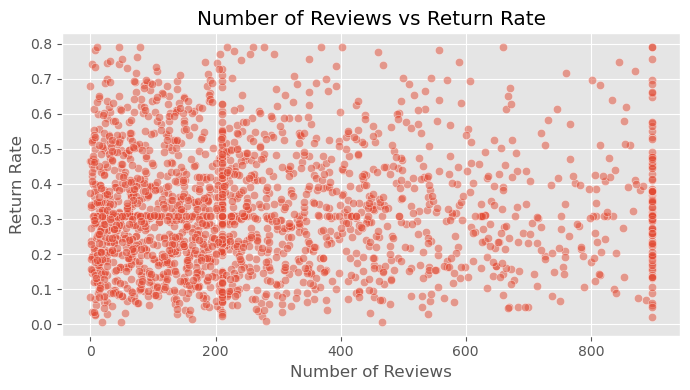

In [75]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df, x='Number_of_Reviews', y='Return_Rate', alpha=0.5)
plt.title('Number of Reviews vs Return Rate')
plt.xlabel('Number of Reviews')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()

*How does return rate vary across product categories?*

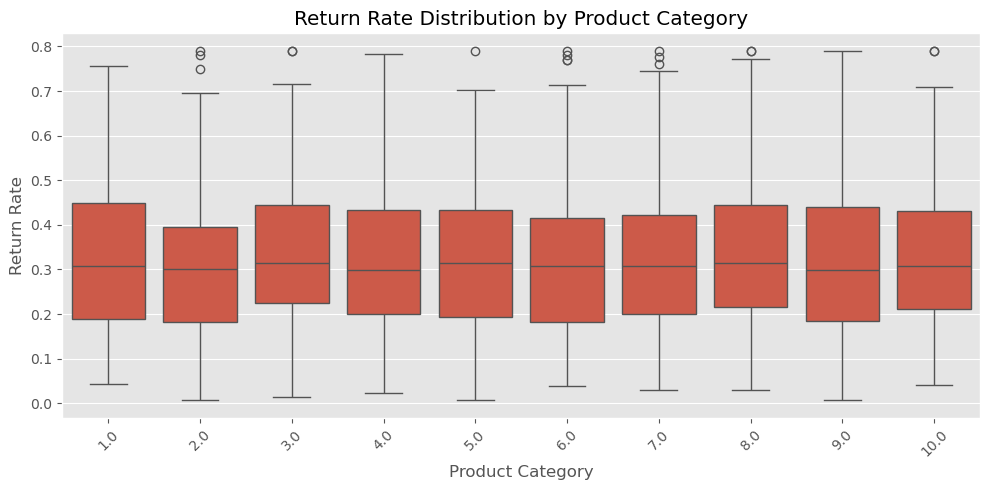

In [76]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Category_ID', y='Return_Rate')
plt.title('Return Rate Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Return Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*What is the average product rating across categories?*

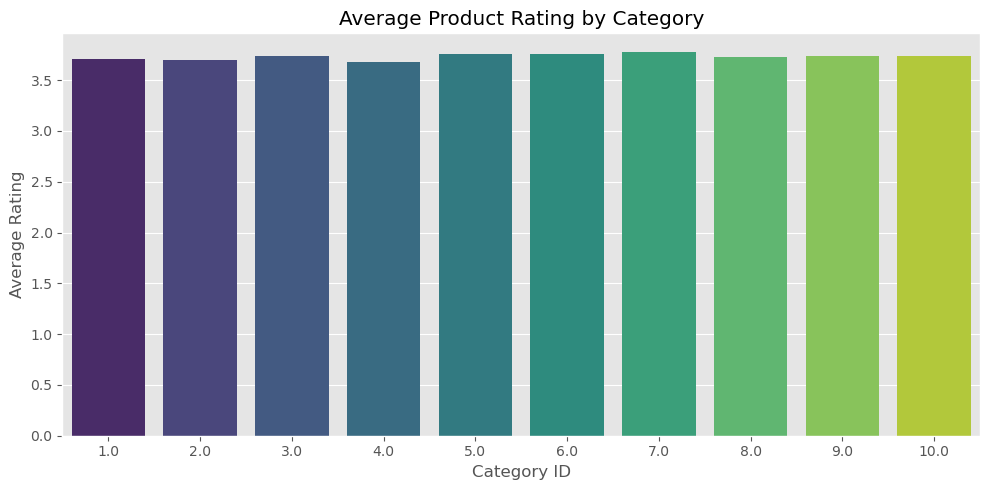

In [77]:
category_rating = df.groupby('Category_ID')['Product_Rating'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=category_rating, x='Category_ID', y='Product_Rating', palette='viridis')
plt.title('Average Product Rating by Category')
plt.xlabel('Category ID')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

*What is the relationship between discount rate and return rate?*

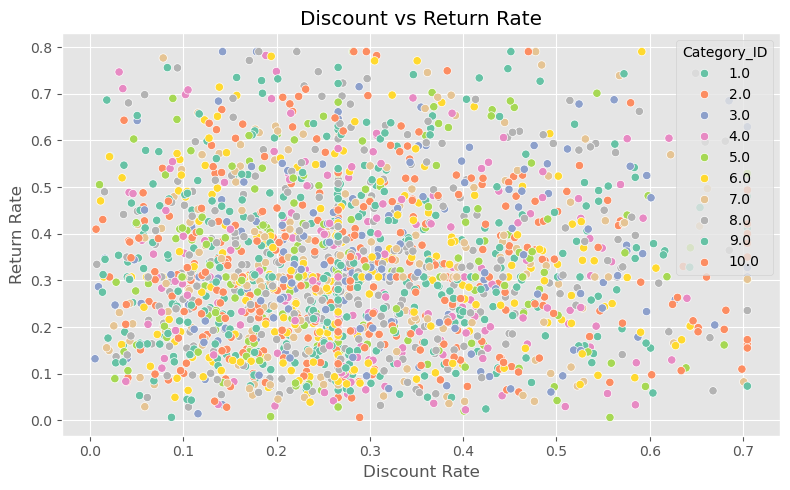

In [78]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount_Rate', y='Return_Rate', hue='Category_ID', palette='Set2')
plt.title('Discount vs Return Rate')
plt.xlabel('Discount Rate')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()

*Are higher-rated products returned less often?*

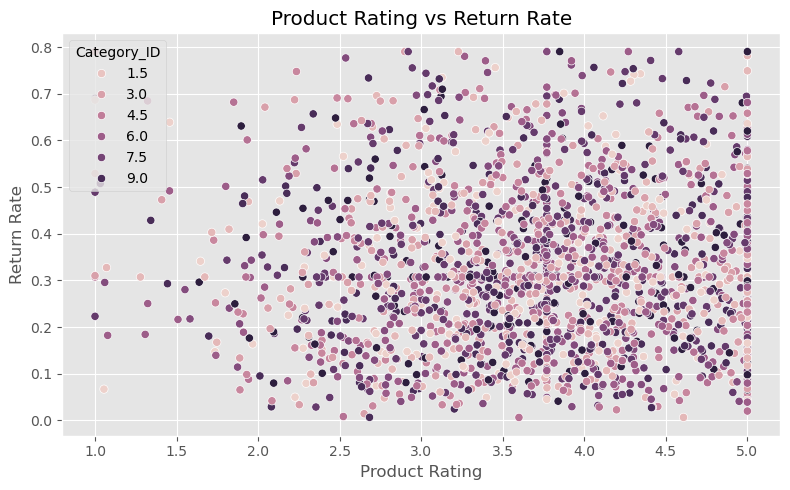

In [79]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Product_Rating', y='Return_Rate', hue='Category_ID')
plt.title('Product Rating vs Return Rate')
plt.xlabel('Product Rating')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()

*Which delivery speeds lead to higher return rates?*

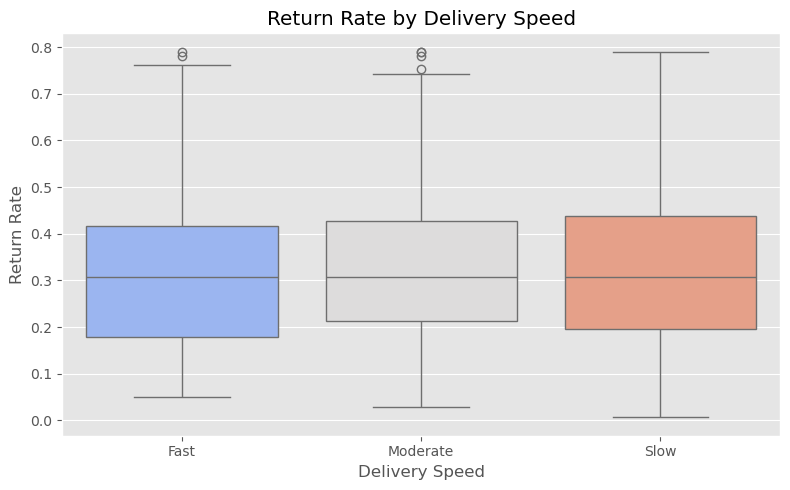

In [80]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Delivery_Speed', y='Return_Rate', palette='coolwarm')
plt.title('Return Rate by Delivery Speed')
plt.xlabel('Delivery Speed')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()

*Does stock availability influence return rates?*

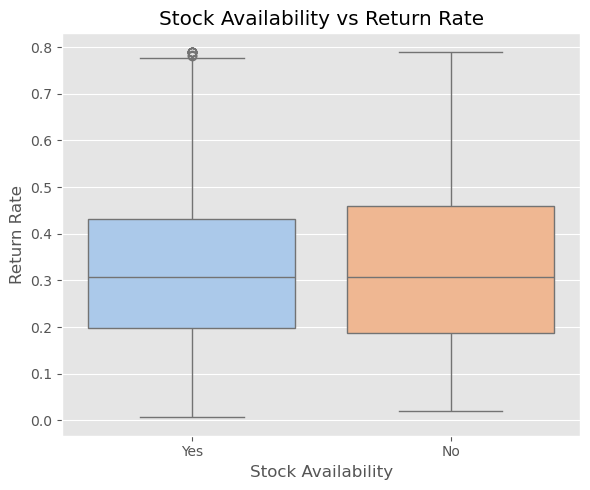

In [81]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Stock_Availability', y='Return_Rate', palette='pastel')
plt.title('Stock Availability vs Return Rate')
plt.xlabel('Stock Availability')
plt.ylabel('Return Rate')
plt.tight_layout()
plt.show()